# Problem Statement



HELP International, a global humanitarian NGO, has raised $10 million to support underdeveloped countries by addressing poverty, improving basic amenities, and providing disaster relief.

The key challenge is to **strategically allocate these limited funds** to maximize impact. The CEO must identify and prioritize countries that are in the most critical need of aid.

As a data scientist, the objective is to:

* Analyze socio-economic and health indicators of various countries
* Categorize countries based on their level of development
* Identify and recommend countries that require immediate attention

---

## 🎯 Objective

To enable **data-driven decision-making** by segmenting countries and highlighting those in the direst need, ensuring optimal utilization of resources.

---

## 💡 Key Value

* **Strategic Allocation**: Direct funds where they are needed most
* **Targeted Interventions**: Address country-specific challenges effectively
* **Maximum Impact**: Improve outcomes for vulnerable populations using data-backed insights


### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Importing Dataset

In [2]:
df = pd.read_csv("data/data.csv")
df_copy = df.copy()
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


### Exploratory Data Analysis

In [3]:
#shape of the dataset
df.shape

(167, 10)

In [4]:
#checking datatypes
df.dtypes

country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

In [5]:
#basic info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


### Missing Values treatment

In [6]:
#checking missing values
df.isna().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

### Outliers Treatment

In [7]:
#defining numeric cols
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
print(numeric_cols)

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp'],
      dtype='object')


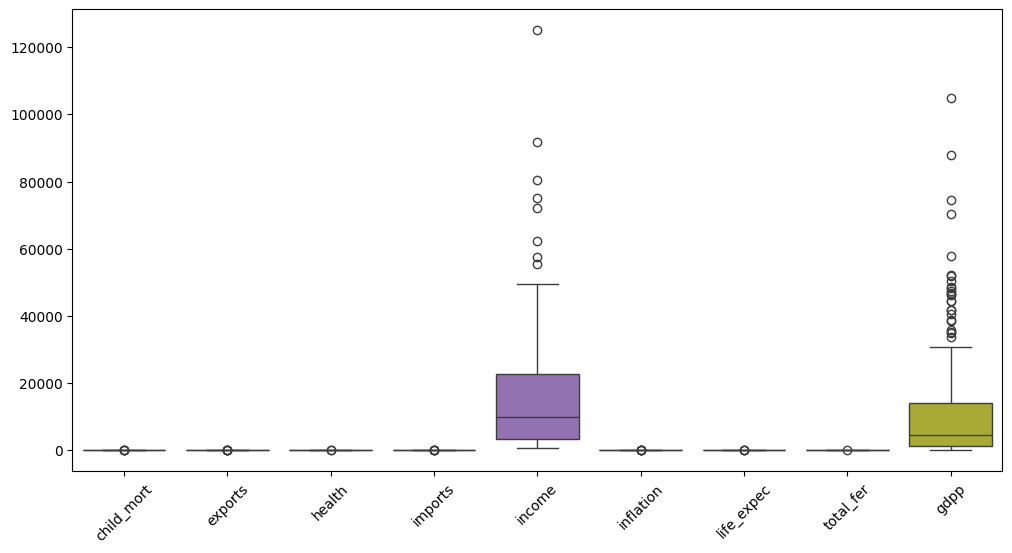

In [8]:
#using boxplot to check, if we have any extreme values in any of the numeric cols
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.show()

We can clearly see that income and gdpp columns shows extreme values stating that there are countries with higher income and higher gdp, which can be considered as an outlier. But, removing them from the dataset doesn't seem correct in the current problem statement.

Now, let's check the skewness of all the numeric cols and then decide, how should we move forward.

In [9]:
#understanding the distribution of the numeric cols
df[numeric_cols].describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [10]:
#checking skewness of all the numeric cols
df[numeric_cols].skew().sort_values(ascending=False)

inflation     5.154049
exports       2.445824
income        2.231480
gdpp          2.218051
imports       1.905276
child_mort    1.450774
total_fer     0.967092
health        0.705746
life_expec   -0.970996
dtype: float64

In [11]:
#checking kurtosis for all the numeric cols
df[numeric_cols].kurt().sort_values(ascending=False)

inflation     41.742502
exports       10.138666
income         7.028657
imports        6.755854
gdpp           5.527891
child_mort     1.766882
life_expec     1.151591
health         0.694196
total_fer     -0.186779
dtype: float64

Based on skewness and kurtosis analysis, I choose to selectively apply log transformation to heavily skewed economic indicators like GDP and income, while leaving variables like inflation untreated due to the presence of negative values and extreme kurtosis, ensuring both statistical stability and real-world interpretability.

Although winsorization was suggested, I opted for log transformation instead, as the outliers represent real-world economic disparities. Log transformation reduces skewness without distorting the relative importance of countries.

#### Performing Log Transform

In [12]:
cols_to_log = ['exports','income','imports','gdpp']

df_log = df.copy()

for col in cols_to_log:
    df_log[col] = np.log1p(df_log[col])

In [13]:
df_log.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,3.553176,6.815689,3.746839,9.115631,7.781832,70.555689,2.947964,8.500171
std,40.328931,0.656774,2.746837,0.540116,1.228722,10.570704,8.893172,1.513848,1.499398
min,2.600000,0.103459,1.810000,0.063820,6.413459,-4.210000,32.100000,1.150000,5.446737
25%,8.250000,3.210844,4.920000,3.440398,8.118495,1.810000,65.300000,1.795000,7.193573
50%,19.300000,3.583519,6.320000,3.790985,9.206433,5.390000,73.100000,2.410000,8.446985
75%,62.100000,3.957951,8.600000,4.090166,10.034550,10.750000,76.800000,3.880000,9.549682
max,208.000000,5.303305,17.900000,5.164786,11.736077,104.000000,82.800000,7.490000,11.561725


#### Checking Skewness and Kurtosis values after log transform

In [14]:
#checking skewness
df_log[numeric_cols].skew().sort_values(ascending=False)

inflation     5.154049
child_mort    1.450774
total_fer     0.967092
health        0.705746
gdpp          0.006548
income       -0.235823
life_expec   -0.970996
exports      -1.088961
imports      -1.822794
dtype: float64

In [15]:
#checking kurtosis
df_log[numeric_cols].kurt().sort_values(ascending=False)

inflation     41.742502
imports       12.154656
exports        4.781681
child_mort     1.766882
life_expec     1.151591
health         0.694196
total_fer     -0.186779
income        -0.845738
gdpp          -0.955381
dtype: float64

After applying log transformation to reduce skewness, I observed extreme kurtosis in inflation. Now, applying capping to inflation, to reduce skewness.

In [16]:
#capping to lower and upper
Q1 = df_log['inflation'].quantile(0.25)
Q3 = df_log['inflation'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_log['inflation'] = df_log['inflation'].clip(lower,upper)

In [17]:
#checking skewness
df_log[numeric_cols].skew().sort_values(ascending=False)

child_mort    1.450774
total_fer     0.967092
inflation     0.966714
health        0.705746
gdpp          0.006548
income       -0.235823
life_expec   -0.970996
exports      -1.088961
imports      -1.822794
dtype: float64

In [18]:
#checking kurtosis
df_log[numeric_cols].kurt().sort_values(ascending=False)

imports       12.154656
exports        4.781681
child_mort     1.766882
life_expec     1.151591
health         0.694196
inflation      0.106547
total_fer     -0.186779
income        -0.845738
gdpp          -0.955381
dtype: float64

#### Univariate Analysis
(Understand distribution, Presence of Outliers, Spread & Variability and Business Meaning)

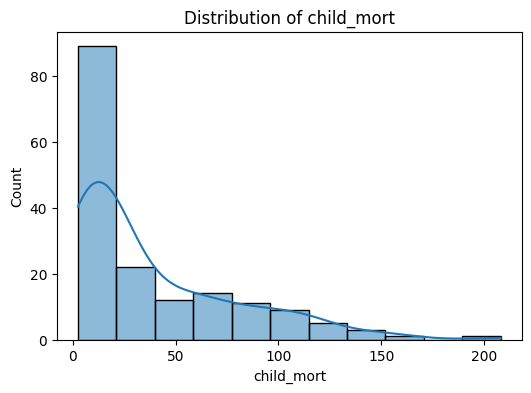

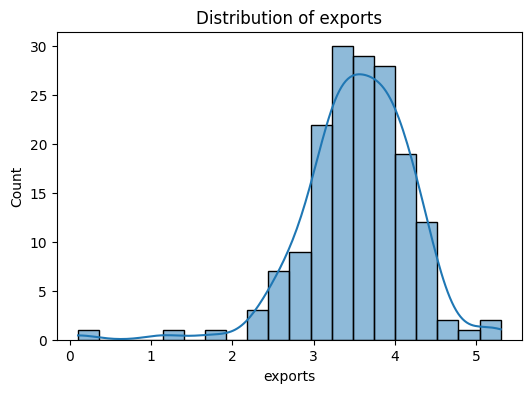

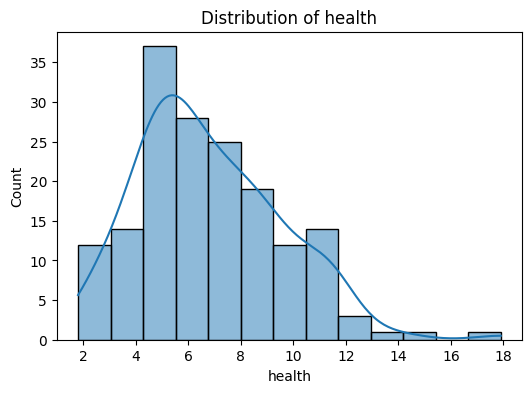

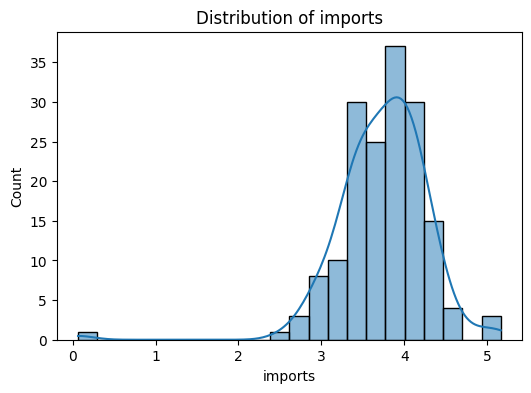

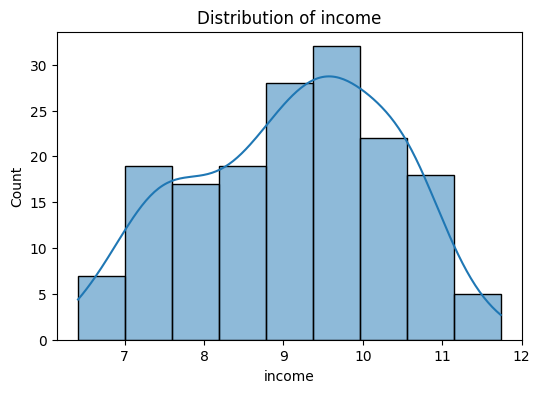

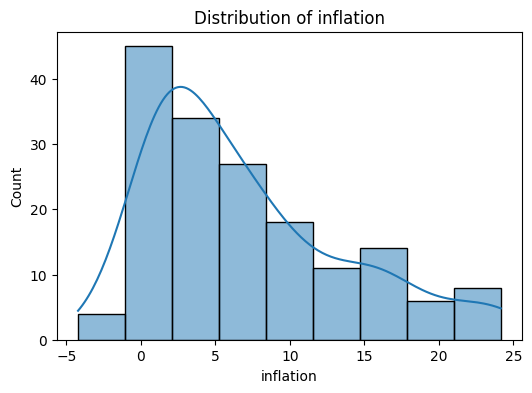

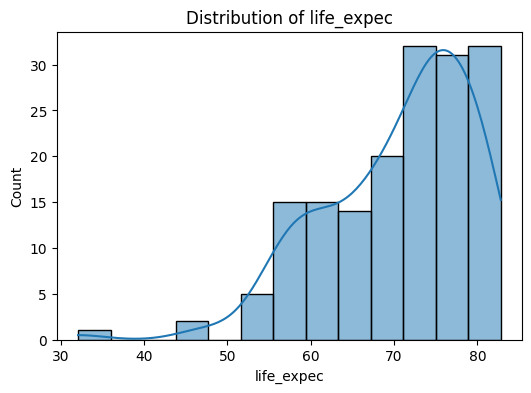

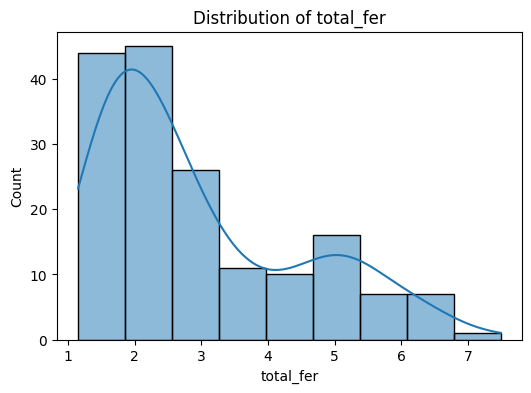

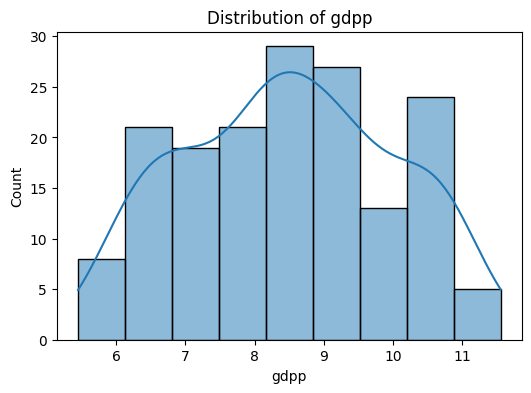

In [19]:
#creating a kde histogram plots to understand the distribution

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df_log[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

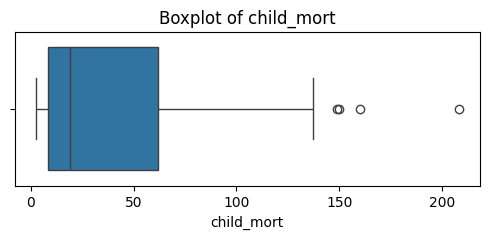

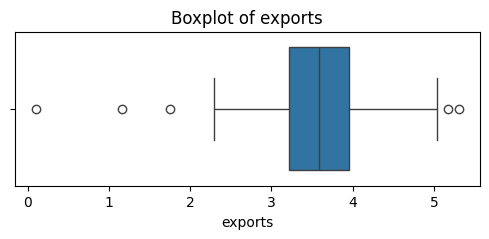

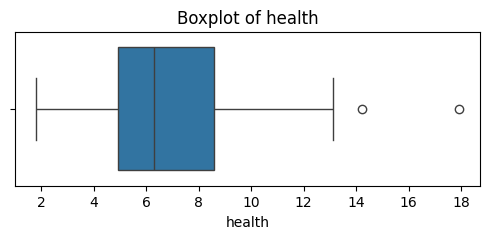

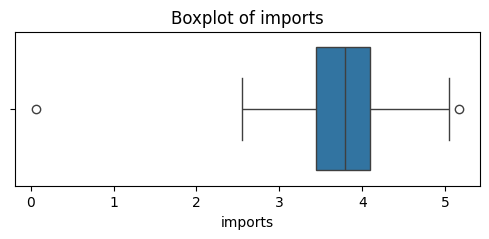

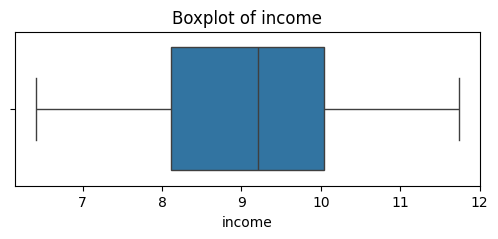

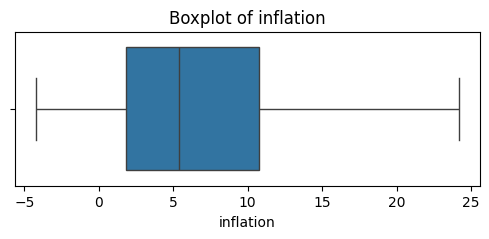

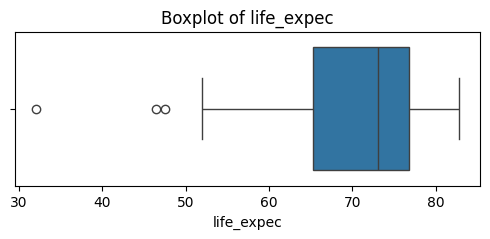

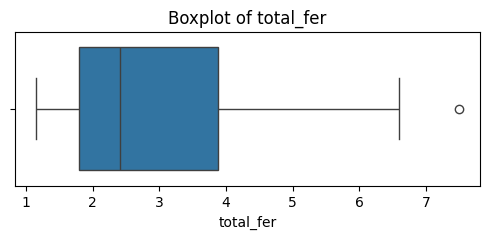

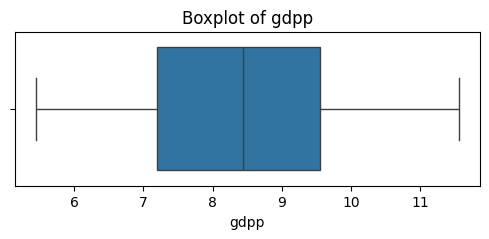

In [20]:
#Boxplots for checking outliers

for col in numeric_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df_log[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

##### Identifying countries which requires immediate financial aid depending on the below metrics,
- High poverty (low income / gdpp)
- High child mortality
- High fertility rate
- Low life expectancy
- Low health spending

In [21]:
#according to high child_mort
df_log.sort_values(by='child_mort', ascending=False)[['country','child_mort']].head(10)

,country,child_mort
66,Haiti,208.0
132,Sierra Leone,160.0
32,Chad,150.0
31,Central African Republic,149.0
97,Mali,137.0
113,Nigeria,130.0
112,Niger,123.0
3,Angola,119.0
25,Burkina Faso,116.0
37,"Congo, Dem. Rep.",116.0


In [22]:
#according to low income
df_log.sort_values(by='income')[['country','income']].head(10)

,country,income
37,"Congo, Dem. Rep.",6.413459
88,Liberia,6.552508
26,Burundi,6.639876
112,Niger,6.703188
31,Central African Republic,6.790097
106,Mozambique,6.823286
94,Malawi,6.938284
63,Guinea,7.082549
150,Togo,7.099202
132,Sierra Leone,7.107425


In [23]:
#according to low gdpp
df_log.sort_values(by='gdpp')[['country','gdpp']].head(10)

,country,gdpp
26,Burundi,5.446737
88,Liberia,5.793014
37,"Congo, Dem. Rep.",5.814131
112,Niger,5.855072
132,Sierra Leone,5.991465
93,Madagascar,6.025866
106,Mozambique,6.040255
31,Central African Republic,6.102559
94,Malawi,6.131226
50,Eritrea,6.180017


In [24]:
#according to low life expectancy
df_log.sort_values(by='life_expec')[['country','life_expec']].head(10)

,country,life_expec
66,Haiti,32.1
87,Lesotho,46.5
31,Central African Republic,47.5
166,Zambia,52.0
94,Malawi,53.1
137,South Africa,54.3
106,Mozambique,54.5
132,Sierra Leone,55.0
64,Guinea-Bissau,55.6
0,Afghanistan,56.2


In [25]:
#according to high fertility
df_log.sort_values(by='total_fer', ascending=False)[['country','total_fer']].head(10)

,country,total_fer
112,Niger,7.49
32,Chad,6.59
97,Mali,6.55
37,"Congo, Dem. Rep.",6.54
26,Burundi,6.26
149,Timor-Leste,6.23
3,Angola,6.16
155,Uganda,6.15
25,Burkina Faso,5.87
113,Nigeria,5.84


In [26]:
#according to low health spending
df_log.sort_values(by='health')[['country','health']].head(10)

,country,health
123,Qatar,1.81
107,Myanmar,1.97
116,Pakistan,2.20
38,"Congo, Rep.",2.46
154,Turkmenistan,2.50
70,Indonesia,2.61
82,Kuwait,2.63
50,Eritrea,2.66
115,Oman,2.77
23,Brunei,2.84


In [27]:
#now, flagging the countries as high risk, and they need immediate financial aid

df_log['risk_score'] = 0

df_log.loc[df_log['child_mort'] > df_log['child_mort'].quantile(0.75), 'risk_score'] += 1
df_log.loc[df_log['total_fer'] > df_log['total_fer'].quantile(0.75), 'risk_score'] += 1
df_log.loc[df_log['life_expec'] < df_log['life_expec'].quantile(0.25), 'risk_score'] += 1
df_log.loc[df_log['income'] < df_log['income'].quantile(0.25), 'risk_score'] += 1
df_log.loc[df_log['health'] < df_log['health'].quantile(0.25), 'risk_score'] += 1
df_log.loc[df_log['inflation'] > df_log['inflation'].quantile(0.75), 'risk_score'] += 1
df_log.loc[df_log['gdpp'] < df_log['gdpp'].quantile(0.25), 'risk_score'] += 1

In [28]:
df_log.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,risk_score
0,Afghanistan,90.2,2.397895,7.58,3.826465,7.384610,9.44,56.2,5.82,6.317165,5
1,Albania,16.6,3.367296,6.55,3.903991,9.203416,4.49,76.3,1.65,8.316545,0
2,Algeria,27.3,3.673766,4.17,3.478158,9.465060,16.10,76.5,2.89,8.403128,2
3,Angola,119.0,4.147885,2.85,3.781914,8.682877,22.40,60.1,6.16,8.169336,5
4,Antigua and Barbuda,10.3,3.839452,6.03,4.092677,9.857496,1.44,76.8,2.13,9.409273,0


In [29]:
#creating category low, medium and high depending on the risk score
def categorize_risk(score):
    if score <= 2:
        return 'low'
    elif score <= 4:
        return 'medium'
    else:
        return 'high'

In [30]:
#creating risk category
df_log['risk_category'] = df_log['risk_score'].apply(categorize_risk)

In [31]:
df_log.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,risk_score,risk_category
0,Afghanistan,90.2,2.397895,7.58,3.826465,7.384610,9.44,56.2,5.82,6.317165,5,high
1,Albania,16.6,3.367296,6.55,3.903991,9.203416,4.49,76.3,1.65,8.316545,0,low
2,Algeria,27.3,3.673766,4.17,3.478158,9.465060,16.10,76.5,2.89,8.403128,2,low
3,Angola,119.0,4.147885,2.85,3.781914,8.682877,22.40,60.1,6.16,8.169336,5,high
4,Antigua and Barbuda,10.3,3.839452,6.03,4.092677,9.857496,1.44,76.8,2.13,9.409273,0,low


In [32]:
#countries falling under high risk category
df_log[df_log['risk_category'] == 'high'][['country','risk_score','risk_category']]

,country,risk_score,risk_category
0,Afghanistan,5,high
3,Angola,5,high
17,Benin,6,high
25,Burkina Faso,5,high
26,Burundi,6,high
28,Cameroon,5,high
31,Central African Republic,6,high
32,Chad,6,high
36,Comoros,5,high
37,"Congo, Dem. Rep.",6,high


Using Univariate analysis, we identified that the above countries needs immediate financial aid, depending on their financial, fertility, humanitary and health conditions

In [33]:
#number of countries per category
df_log['risk_category'].value_counts()

risk_category
low       119
high       33
medium     15
Name: count, dtype: int64

In [34]:
#list of medium countries
df_log[df_log['risk_category'] == 'medium'][['country','risk_score','risk_category']]

,country,risk_score,risk_category
12,Bangladesh,3,medium
56,Gambia,4,medium
66,Haiti,4,medium
81,Kiribati,3,medium
84,Lao,4,medium
87,Lesotho,4,medium
107,Myanmar,3,medium
109,Nepal,3,medium
113,Nigeria,4,medium
116,Pakistan,4,medium


Countries falling under medium risk, might need some help, depending on their financial, fertility, humanitary and health conditions

In [35]:
#checking where India stands
df_log[df_log['country'] == 'India']

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,risk_score,risk_category
69,India,58.8,3.161247,4.05,3.33577,8.391857,8.98,66.2,2.6,7.2086,1,low


India, is in the great position. It doesn't require any help, instead along with other super power countries, it can help to contribute to high risk countries

In [36]:
#checking low risk countries
df_log[df_log['risk_category'] == 'low'][['country','risk_score','risk_category']].sort_values(by='risk_score', ascending=True).head(10)

,country,risk_score,risk_category
1,Albania,0,low
92,"Macedonia, FYR",0,low
91,Luxembourg,0,low
90,Lithuania,0,low
153,Turkey,0,low
86,Lebanon,0,low
85,Latvia,0,low
78,Jordan,0,low
77,Japan,0,low
75,Italy,0,low


#### Bivariate Analysis

In [37]:
df_log.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,risk_score,risk_category
0,Afghanistan,90.2,2.397895,7.58,3.826465,7.384610,9.44,56.2,5.82,6.317165,5,high
1,Albania,16.6,3.367296,6.55,3.903991,9.203416,4.49,76.3,1.65,8.316545,0,low
2,Algeria,27.3,3.673766,4.17,3.478158,9.465060,16.10,76.5,2.89,8.403128,2,low
3,Angola,119.0,4.147885,2.85,3.781914,8.682877,22.40,60.1,6.16,8.169336,5,high
4,Antigua and Barbuda,10.3,3.839452,6.03,4.092677,9.857496,1.44,76.8,2.13,9.409273,0,low


In [38]:
print(numeric_cols)

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp'],
      dtype='object')


In [39]:
#understanding the linear relationship between the numerical features
corr_matrix = df_log[numeric_cols].corr()
print(corr_matrix)

            child_mort   exports    health   imports    income  inflation  \
child_mort    1.000000 -0.355954 -0.200402 -0.100664 -0.775109   0.303186   
exports      -0.355954  1.000000 -0.074494  0.665583  0.510340  -0.126328   
health       -0.200402 -0.074494  1.000000  0.126102  0.149877  -0.337904   
imports      -0.100664  0.665583  0.126102  1.000000  0.020655  -0.262542   
income       -0.775109  0.510340  0.149877  0.020655  1.000000  -0.219894   
inflation     0.303186 -0.126328 -0.337904 -0.262542 -0.219894   1.000000   
life_expec   -0.886676  0.315988  0.210692  0.012712  0.805912  -0.300225   
total_fer     0.848478 -0.347514 -0.196674 -0.082686 -0.771243   0.365969   
gdpp         -0.754124  0.465639  0.270389  0.043145  0.972024  -0.294781   

            life_expec  total_fer      gdpp  
child_mort   -0.886676   0.848478 -0.754124  
exports       0.315988  -0.347514  0.465639  
health        0.210692  -0.196674  0.270389  
imports       0.012712  -0.082686  0.043145  

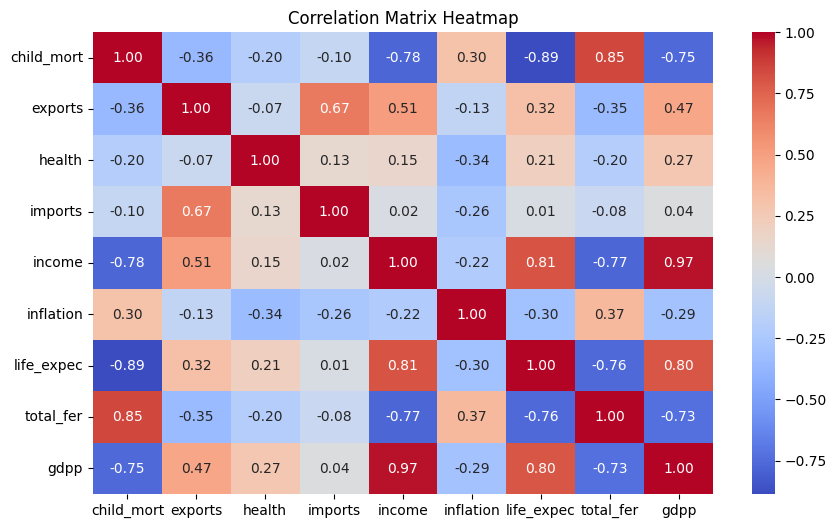

In [40]:
#plotting heatmap to better understand the linear relationships
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

The correlation analysis revealed strong relationships between economic and health indicators. Child mortality showed a strong negative correlation with life expectancy and income, indicating poorer countries face worse health outcomes. Income and GDP per capita were highly correlated, suggesting redundancy. Fertility rate emerged as a key indicator, strongly associated with both mortality and life expectancy. Inflation showed weak relationships, indicating limited direct impact.

Now, validating the relationships by plotting the scatter plots

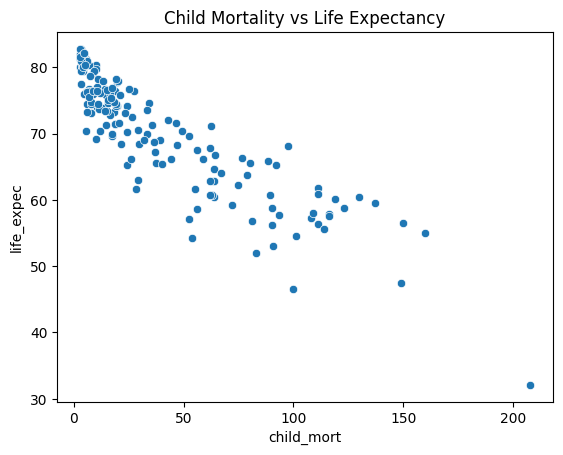

In [41]:
#child_mort Vs life expectancy
sns.scatterplot(x='child_mort', y='life_expec', data=df_log)
plt.title("Child Mortality vs Life Expectancy")
plt.show()

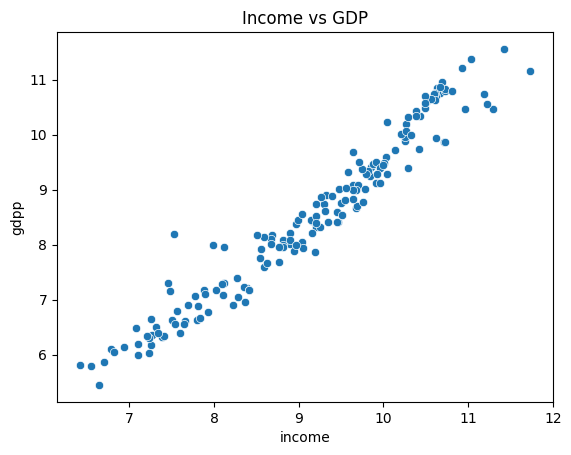

In [42]:
#Income Vs GDP
sns.scatterplot(x='income', y='gdpp', data=df_log)
plt.title("Income vs GDP")
plt.show()

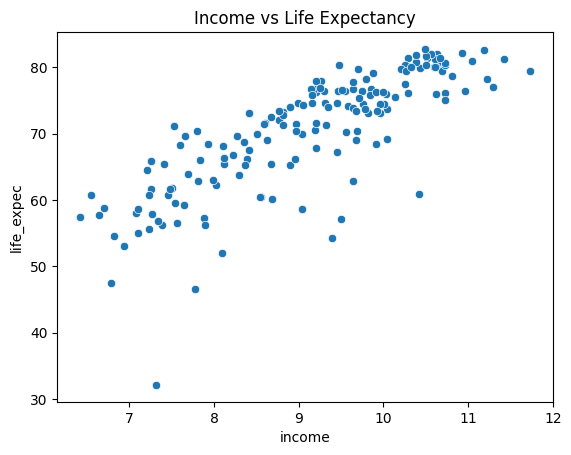

In [43]:
#Income vs Life Expectancy
sns.scatterplot(x='income', y='life_expec', data=df_log)
plt.title("Income vs Life Expectancy")
plt.show()

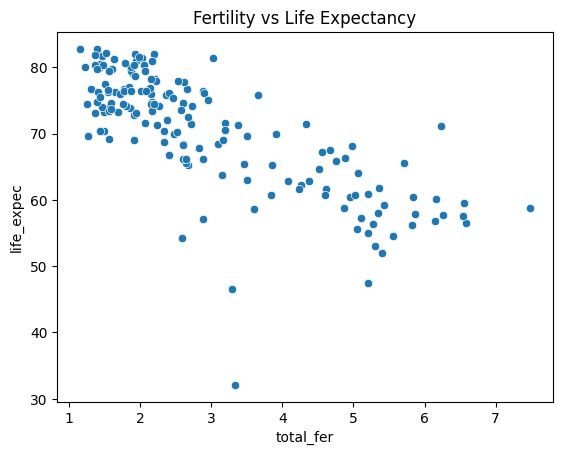

In [44]:
#Fertility Vs Life Expectancy
sns.scatterplot(x='total_fer', y='life_expec', data=df_log)
plt.title("Fertility vs Life Expectancy")
plt.show()

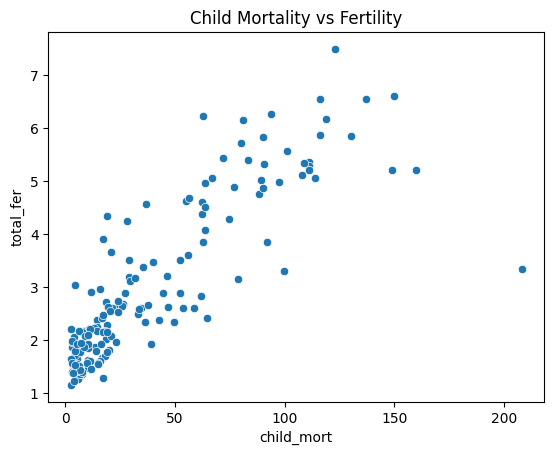

In [45]:
#Child Mortality Vs Life Fertility
sns.scatterplot(x='child_mort', y='total_fer', data=df_log)
plt.title("Child Mortality vs Fertility")
plt.show()

#### Hypothesis testing

##### Statistical test to check mean life expectancy with High and Low Heath spending Countries.

Defining Hypothesis:

Null Hypothesis (Ho): There is no difference in life expectancy between high and low health spending countries

Alternate Hypothesis (Ha): Countries with higher health spending have higher life expectancy

In [46]:
#creating threshold
threshold = df_log['health'].median()

#Split data into two groups
high_health = df_log[df_log['health'] >= threshold]['life_expec']
low_health = df_log[df_log['health'] < threshold]['life_expec']

In [47]:
#checking mean for both the groups
print("High Health Mean Life Expectancy:", high_health.mean())
print("Low Health Mean Life Expectancy:", low_health.mean())

High Health Mean Life Expectancy: 72.46785714285713
Low Health Mean Life Expectancy: 68.62048192771083


In [48]:
#performing ttest
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(high_health, low_health)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 2.854866762292306
P-value: 0.004858447012381934


Since p_value < 0.05, we reject the Ho, the t-test confirms a statistically significant association between health spending and life expectancy, but it does not imply causation.

##### Statistical test to check mean Income with High and Low Fertility Countries.


In [49]:
#checking correlation betweem income and total_fertility
corr = df_log['total_fer'].corr(df_log['income'])
print("Correlation:", corr)

Correlation: -0.7712430708208398


Income and Total Fertility is negatively correlated with each other that means Countries with higher income shows low fertility

Defining Hypothesis:

Null Hypothesis (Ho):There is no relationship between fertility rate and income

Alternate Hypothesis (Ha):Countries with higher fertility have lower income

In [50]:
#creating threshold
threshold = df_log['total_fer'].median()

high_fert = df_log[df_log['total_fer'] >= threshold]['income']
low_fert = df_log[df_log['total_fer'] < threshold]['income']

In [51]:
#checking mean for both the groups
print("High Fertility Income:", high_fert.mean())
print("Low Fertility Income:", low_fert.mean())

High Fertility Income: 8.295127785210374
Low Fertility Income: 9.946019136206154


In [52]:
#performing ttest
t_stat, p_value = ttest_ind(high_fert, low_fert)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -11.71331528167213
P-value: 1.9004625932288598e-23


Here, we can clearly see that p_value < 0.05 that means, we reject Null Hypothesis and it's confirmed that Countries with lower incomes have High fertility and vice versa.

##### Statistical test to check Child Mortality with High and Low Income Countries.

Defining Hypothesis:

Null Hypothesis (Ho): There is no relationship between income and child mortality

Alternate Hypothesis (Ha): Higher income is associated with lower child mortality

In [53]:
#creating threshold
threshold = df_log['income'].median()

high_income = df_log[df_log['income'] >= threshold]['child_mort']
low_income = df_log[df_log['income'] < threshold]['child_mort']

In [54]:
#checking mean for both the groups
print("High Income Child Mortality:", high_income.mean())
print("Low Income Child Mortality:", low_income.mean())

High Income Child Mortality: 13.222619047619045
Low Income Child Mortality: 63.61927710843375


There is major difference in Child Mortality between the high and low income countries.

In [55]:
#performing ttest
t_stat, p_value = ttest_ind(high_income, low_income)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -10.330119195866995
P-value: 1.3185219089231024e-19


Here, we can clearly see that p_value < 0.05 that means, we reject Null Hypothesis, Higher income is associated with Lower Child Mortality rate and vice versa.

##### Statistical test to check GDP with High and Low Inflation rates.

Defining Hypothesis:

Null Hypothesis (Ho): There is no relationship between inflation and GDP per capita

Alternate Hypothesis (Ha): Higher inflation is associated with lower GDP per capita

In [56]:
#creating threshold
threshold = df_log['inflation'].median()

high_inflation = df_log[df_log['inflation'] >= threshold]['gdpp']
low_inflation = df_log[df_log['inflation'] < threshold]['gdpp']

In [57]:
#checking means
print("High Inflation GDP per capita:", high_inflation.mean())
print("Low Inflation GDP per capita:", low_inflation.mean())

High Inflation GDP per capita: 8.017207247844315
Low Inflation GDP per capita: 8.988953823924763


In [58]:
#performing ttest
t_stat, p_value = ttest_ind(high_inflation, low_inflation)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -4.414555711978686
P-value: 1.8233152216043528e-05


Here, we can clearly see that p_value < 0.05 that means, we reject Null Hypothesis, Higher inflation is associated with lower GDP per capita and vice versa.

In [59]:
#Creating new features
# High child mortality
df_log['high_child_mort'] = (df_log['child_mort'] > df_log['child_mort'].quantile(0.75)).astype(int)

# Low income
df_log['low_income'] = (df_log['income'] < df_log['income'].quantile(0.25)).astype(int)

# High inflation
df_log['high_inflation'] = (df_log['inflation'] > df_log['inflation'].quantile(0.75)).astype(int)

# Low life expectancy
df_log['low_life_expec'] = (df_log['life_expec'] < df_log['life_expec'].quantile(0.25)).astype(int)

In [60]:
thresholds = {
    "child_mort_75": df_log['child_mort'].quantile(0.75),
    "income_25": df_log['income'].quantile(0.25),
    "inflation_75": df_log['inflation'].quantile(0.75),
    "life_expec_25": df_log['life_expec'].quantile(0.25),
    "inflation_lower": lower,
    "inflation_upper": upper
}

In [61]:
print(thresholds)

{'child_mort_75': np.float64(62.1), 'income_25': np.float64(8.118495078795409), 'inflation_75': np.float64(10.75), 'life_expec_25': np.float64(65.3), 'inflation_lower': np.float64(-11.6), 'inflation_upper': np.float64(24.16)}


##### Dropping categorical columns

In [62]:
# Keep original dataframe
df_original = df_log.copy()

# Create model dataset (without country)
df_model = df_log.drop(['country', 'risk_score', 'risk_category'], axis=1)

I excluded the country column from clustering as it is a categorical identifier and does not contribute to distance-based learning. However, I retained it in the original dataset to map clusters back to countries for interpretation.

In [63]:
df_model.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,high_child_mort,low_income,high_inflation,low_life_expec
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,3.553176,6.815689,3.746839,9.115631,7.065066,70.555689,2.947964,8.500171,0.251497,0.251497,0.251497,0.245509
std,40.328931,0.656774,2.746837,0.540116,1.228722,6.704968,8.893172,1.513848,1.499398,0.435178,0.435178,0.435178,0.431683
min,2.600000,0.103459,1.810000,0.063820,6.413459,-4.210000,32.100000,1.150000,5.446737,0.000000,0.000000,0.000000,0.000000
25%,8.250000,3.210844,4.920000,3.440398,8.118495,1.810000,65.300000,1.795000,7.193573,0.000000,0.000000,0.000000,0.000000
50%,19.300000,3.583519,6.320000,3.790985,9.206433,5.390000,73.100000,2.410000,8.446985,0.000000,0.000000,0.000000,0.000000
75%,62.100000,3.957951,8.600000,4.090166,10.034550,10.750000,76.800000,3.880000,9.549682,0.500000,0.500000,0.500000,0.000000
max,208.000000,5.303305,17.900000,5.164786,11.736077,24.160000,82.800000,7.490000,11.561725,1.000000,1.000000,1.000000,1.000000


Since Unsupervised algorithmns are distance based like Kmeans, its important to normalize all features using MinMaxScaler to ensure equal contribution from each variable and to prevent features with larger scales from dominating the clustering process.

#### Scaling the DataFrame

In [64]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = scaler.fit_transform(df_model)

In [65]:
df_scaled = pd.DataFrame(df_scaled, columns=df_model.columns)

In [66]:
df_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,high_child_mort,low_income,high_inflation,low_life_expec
0,0.426485,0.441251,0.358608,0.737634,0.182457,0.481142,0.475345,0.736593,0.142343,1.0,1.0,0.0,1.0
1,0.068160,0.627680,0.294593,0.752832,0.524170,0.306662,0.871795,0.078864,0.469307,0.0,0.0,0.0,0.0
2,0.120253,0.686618,0.146675,0.669351,0.573327,0.715897,0.875740,0.274448,0.483466,0.0,0.0,1.0,0.0
3,0.566699,0.777797,0.064636,0.728900,0.426373,0.937963,0.552268,0.790221,0.445234,1.0,0.0,1.0,1.0
4,0.037488,0.718482,0.262275,0.789822,0.647057,0.199154,0.881657,0.154574,0.648004,0.0,0.0,0.0,0.0


In [67]:
#quick check
df_scaled.describe().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,high_child_mort,low_income,high_inflation,low_life_expec
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,0.17,0.66,0.31,0.72,0.51,0.40,0.76,0.28,0.50,0.25,0.25,0.25,0.25
std,0.20,0.13,0.17,0.11,0.23,0.24,0.18,0.24,0.25,0.44,0.44,0.44,0.43
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.03,0.60,0.19,0.66,0.32,0.21,0.65,0.10,0.29,0.00,0.00,0.00,0.00
50%,0.08,0.67,0.28,0.73,0.52,0.34,0.81,0.20,0.49,0.00,0.00,0.00,0.00
75%,0.29,0.74,0.42,0.79,0.68,0.53,0.88,0.43,0.67,0.50,0.50,0.50,0.00
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


#### Training Models

In [68]:
#finding the optimal k using elbow method

from sklearn.cluster import KMeans

inertia = []

K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Strategic Aid Allocation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Strategic Aid Allocation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Strategic Aid Allocation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Strategic Aid Allocation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Strategic Aid Allocation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWa

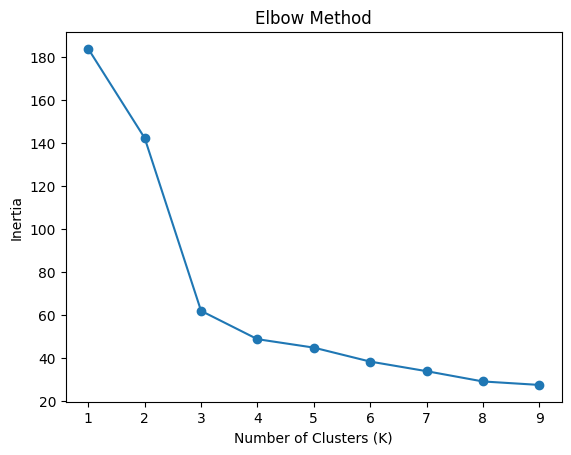

In [69]:
#plotting K Vs Inertia to get the optimal k

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

After observing the above graph K Vs Inertia, it is clear that the optimal K is either 2,3 or 4.

In [70]:
#now checking the silhouette score

from sklearn.metrics import silhouette_score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    
    score = silhouette_score(df_scaled, labels)
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.3513896631710412
K=3, Silhouette Score=0.5032897339404309
K=4, Silhouette Score=0.506615623728353
K=5, Silhouette Score=0.5095858768466316
K=6, Silhouette Score=0.3728774233534679
K=7, Silhouette Score=0.37722767667261325
K=8, Silhouette Score=0.3855166296658766
K=9, Silhouette Score=0.3349656770528175


/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Strategic Aid Allocation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Strategic Aid Allocation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Strategic Aid Allocation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Strategic Aid Allocation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Strategic Aid Allocation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWa

Although k=5 gave the highest silhouette score, the improvement over k=3 was marginal. I selected k=3 to balance clustering performance with business interpretability, enabling meaningful segmentation into high, medium, and low-risk countries.

In [71]:
#training Kmeans model
kmeans = KMeans(n_clusters=3, random_state=42)
df_clusters = kmeans.fit_predict(df_scaled)

/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Strategic Aid Allocation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Strategic Aid Allocation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Strategic Aid Allocation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [72]:
#adding the cluster to data
df_log['cluster_kmeans'] = df_clusters

In [73]:
df_log.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,risk_score,risk_category,high_child_mort,low_income,high_inflation,low_life_expec,cluster_kmeans
0,Afghanistan,90.2,2.397895,7.58,3.826465,7.384610,9.44,56.2,5.82,6.317165,5,high,1,1,0,1,1
1,Albania,16.6,3.367296,6.55,3.903991,9.203416,4.49,76.3,1.65,8.316545,0,low,0,0,0,0,0
2,Algeria,27.3,3.673766,4.17,3.478158,9.465060,16.10,76.5,2.89,8.403128,2,low,0,0,1,0,2
3,Angola,119.0,4.147885,2.85,3.781914,8.682877,22.40,60.1,6.16,8.169336,5,high,1,0,1,1,1
4,Antigua and Barbuda,10.3,3.839452,6.03,4.092677,9.857496,1.44,76.8,2.13,9.409273,0,low,0,0,0,0,0


##### Visualizing clusters

In [74]:
#applying PCA for dimensionality reduction

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

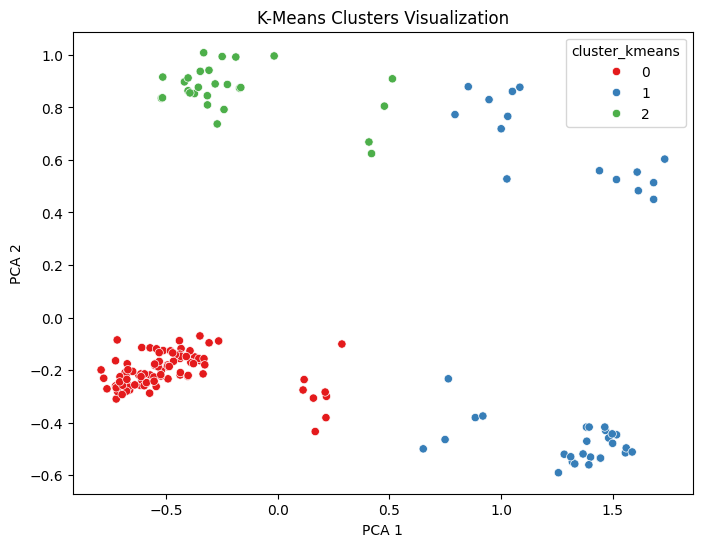

In [75]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df_pca[:,0],y=df_pca[:,1],hue=df_log['cluster_kmeans'],palette='Set1')
plt.title("K-Means Clusters Visualization")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [76]:
#checking Silhouette score
from sklearn.metrics import silhouette_score

score = silhouette_score(df_scaled, df_log['cluster_kmeans'])
print("Silhouette Score:", score)

Silhouette Score: 0.5032897339404309


/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Strategic Aid Allocation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Strategic Aid Allocation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Strategic Aid Allocation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [77]:
numeric_cols = df_log.select_dtypes(include=['int64', 'float64']).columns
df_log.groupby('cluster_kmeans')[numeric_cols].mean().T

cluster_kmeans,0,1,2
child_mort,16.734694,95.292857,27.733333
exports,3.680597,3.229772,3.593763
health,7.450816,6.379286,5.189259
imports,3.803351,3.751163,3.534994
income,9.685034,7.600180,9.406276
inflation,3.441235,9.569167,16.322963
life_expec,75.280612,58.814286,71.670370
total_fer,2.107755,5.145000,2.580000
gdpp,9.223079,6.829325,8.475379
risk_score,0.316327,5.023810,1.888889


🔴 Cluster 1 → High Risk (Needs Immediate Aid)

👉 This cluster clearly stands out as the most vulnerable group

Key Signals:
Child Mortality: Extremely high (~95) 🚨
Life Expectancy: Very low (~58) 🚨
Total Fertility: Very high (~5.1) 🚨
Income & GDP: Low (~7.6, ~6.8) 💸
Risk Score: Highest (~5.0) 🚨
Low Income Countries: ~86%
High Child Mortality: ~93%
Low Life Expectancy: ~90%
🧾 Interpretation:

👉 These countries are:

Poor
Have weak healthcare systems
High population growth
Poor living conditions
✅ Conclusion:

This cluster represents countries in the direst need of financial and humanitarian aid.

🟡 Cluster 2 → Medium Risk (Economically Unstable)

👉 These are not the poorest, but show instability

Key Signals:
Inflation: Extremely high (~16.3) 🚨
Health Spending: Lowest (~5.18)
Child Mortality: Moderate (~27)
Life Expectancy: Decent (~71.6)
Income & GDP: Moderate
🧾 Interpretation:

👉 These countries:

Have economic instability (high inflation)
Moderate development
Healthcare could be improved
✅ Conclusion:

This cluster represents countries that are economically unstable and may require targeted financial and policy support.

🟢 Cluster 0 → Low Risk (Developed / Stable)

👉 This is the most developed group

Key Signals:
Child Mortality: Very low (~16.7) ✅
Life Expectancy: High (~75.3) ✅
Income & GDP: High (~9.68, ~9.22) 💰
Fertility Rate: Low (~2.1)
Risk Score: Very low (~0.3)
🧾 Interpretation:

👉 These countries:

Have strong economies
Good healthcare systems
Stable populations
✅ Conclusion:

This cluster represents developed countries with low priority for aid allocation.

In [78]:
#Below are the most critical countries
df_log[df_log['cluster_kmeans'] == 1].sort_values(by=['child_mort', 'income'], ascending=[False, True])[['country', 'child_mort', 'income', 'life_expec']].head(10)

,country,child_mort,income,life_expec
66,Haiti,208.0,7.313887,32.1
132,Sierra Leone,160.0,7.107425,55.0
32,Chad,150.0,7.565793,56.5
31,Central African Republic,149.0,6.790097,47.5
97,Mali,137.0,7.534228,59.5
113,Nigeria,130.0,8.546946,60.5
112,Niger,123.0,6.703188,58.8
3,Angola,119.0,8.682877,60.1
37,"Congo, Dem. Rep.",116.0,6.413459,57.5
25,Burkina Faso,116.0,7.266129,57.9


The clustering results align strongly with real-world development patterns, successfully separating underdeveloped nations from more stable economies, enabling targeted and impactful aid allocation.

##### Training Hierarchical Clustering

In [79]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3)
hc_clusters = hc.fit_predict(df_scaled)

In [80]:
score_hc = silhouette_score(df_scaled, hc_clusters)
print("Hierarchical Silhouette Score:", score_hc)

Hierarchical Silhouette Score: 0.4797096306477812


/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Strategic Aid Allocation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Strategic Aid Allocation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/prathameshkamble/Desktop/Scaler/Portfolio projects/Strategic Aid Allocation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


** K-Means gave us the better results than Hierachical Clustering. So, using K-Means as my final model. **

In [81]:
#saving the model artifacts
import joblib
joblib.dump(kmeans, 'model/kmeans_model.pkl')
joblib.dump(scaler, 'model/scaler.pkl')
joblib.dump(df_log.columns.tolist(), 'model/features.pkl')
joblib.dump(thresholds, 'model/thresholds.pkl')

['model/thresholds.pkl']

In [82]:
df_log.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,risk_score,risk_category,high_child_mort,low_income,high_inflation,low_life_expec,cluster_kmeans
0,Afghanistan,90.2,2.397895,7.58,3.826465,7.384610,9.44,56.2,5.82,6.317165,5,high,1,1,0,1,1
1,Albania,16.6,3.367296,6.55,3.903991,9.203416,4.49,76.3,1.65,8.316545,0,low,0,0,0,0,0
2,Algeria,27.3,3.673766,4.17,3.478158,9.465060,16.10,76.5,2.89,8.403128,2,low,0,0,1,0,2
3,Angola,119.0,4.147885,2.85,3.781914,8.682877,22.40,60.1,6.16,8.169336,5,high,1,0,1,1,1
4,Antigua and Barbuda,10.3,3.839452,6.03,4.092677,9.857496,1.44,76.8,2.13,9.409273,0,low,0,0,0,0,0


In [83]:
#saving the processed data for creating dashboards

df_log.to_csv("data/processed_data.csv", index=False)